**Vector to raster**

Convert a shapefile to a raster

In [1]:
# Load libraries

import os
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.features import rasterize
from google.colab import drive
from rasterio.transform import from_origin
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
# Mount the drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Specify link to directory where raster files are saved

costarica_shapefile = '/content/drive/MyDrive/GitHub_Desktop/Work/Data/CostaRica_PeatlandMap'

In [4]:
# List the files in the directory

file_paths = os.listdir(costarica_shapefile)
file_paths

['CostaRica_PeatlandMap.sbn',
 'CostaRica_PeatlandMap.prj',
 'CostaRica_PeatlandMap.cpg',
 'CostaRica_PeatlandMap.shp.xml',
 'CostaRica_PeatlandMap.dbf',
 'CostaRica_PeatlandMap.shp',
 'CostaRica_PeatlandMap.sbx',
 'CostaRica_PeatlandMap.shx',
 'CostaRica_PeatlandMap.tif']

In [5]:
# Load shapefile & set output raster

# Load shapefile & set output raster
vector_path = '/content/drive/MyDrive/GitHub_Desktop/Work/Data/CostaRica_PeatlandMap/CostaRica_PeatlandMap.shp'
output_raster = '/content/drive/MyDrive/GitHub_Desktop/Work/Data/CostaRica_PeatlandMap/CostaRica_PeatlandMap.tif'

# Read shapefile
gdf = gpd.read_file(vector_path)

# Print metadata
print("CRS:", gdf.crs)
print("Fields:", gdf.columns)
print("Number of features:", len(gdf))

CRS: EPSG:4326
Fields: Index(['Id', 'gridcode', 'PROBABILIT', 'Shape_Leng', 'Shape_Area', 'geometry'], dtype='object')
Number of features: 2639


In [6]:
# Load shapefile & set output raster

# Load shapefile & set output raster
vector_path = '/content/drive/MyDrive/GitHub_Desktop/Work/Data/CostaRica_PeatlandMap/CostaRica_PeatlandMap.shp'
output_raster = '/content/drive/MyDrive/GitHub_Desktop/Work/Data/CostaRica_PeatlandMap/CostaRica_PeatlandMap.tif'

# Read shapefile
gdf = gpd.read_file(vector_path)

# Print metadata
print("CRS:", gdf.crs)
print("Fields:", gdf.columns)
print("Number of features:", len(gdf))

CRS: EPSG:4326
Fields: Index(['Id', 'gridcode', 'PROBABILIT', 'Shape_Leng', 'Shape_Area', 'geometry'], dtype='object')
Number of features: 2639


Classes: [np.int64(0), np.int64(4), np.int64(5)]


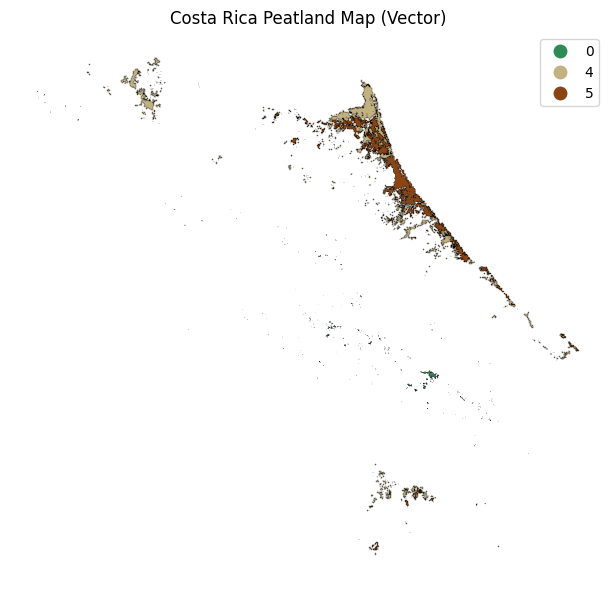

In [7]:
# Visualise shapeflie

# Choose attribute field
attribute_field = "gridcode"

# Get unique classes
classes = sorted(gdf[attribute_field].unique())
print("Classes:", classes)

# Custom colour scheme (edit if needed)
class_colors = [
    "#2E8B57",  # green
    "#C2B280",  # beige
    "#8B4513"   # brown
]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

gdf.plot(
    column=attribute_field,
    categorical=True,
    legend=True,
    cmap=plt.matplotlib.colors.ListedColormap(class_colors[:len(classes)]),
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

ax.set_title("Costa Rica Peatland Map (Vector)")
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [8]:
# Get bounds

print("Original CRS:", gdf.crs)

# Reproject to UTM Zone 16N (meters)
gdf = gdf.to_crs("EPSG:32616")

attribute_field = "gridcode"
pixel_size = 30                # Set resolution

minx, miny, maxx, maxy = gdf.total_bounds

width = int((maxx - minx) / pixel_size)
height = int((maxy - miny) / pixel_size)

transform = from_origin(minx, maxy, pixel_size, pixel_size)

Original CRS: EPSG:4326


In [9]:
# Prepare shapes

shapes = (
    (geom, value)
    for geom, value in zip(gdf.geometry, gdf[attribute_field])
)

In [10]:
print(gdf[attribute_field].unique())
print(gdf[attribute_field].describe())

[4 5 0]
count    2639.000000
mean        3.664267
std         1.517717
min         0.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: gridcode, dtype: float64


In [11]:
# Rasterize

raster = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=-9999,
    dtype="float32"
)

In [12]:
np.unique(raster)

array([-9.999e+03,  0.000e+00,  4.000e+00,  5.000e+00], dtype=float32)

Unique classes: [0. 4. 5.]


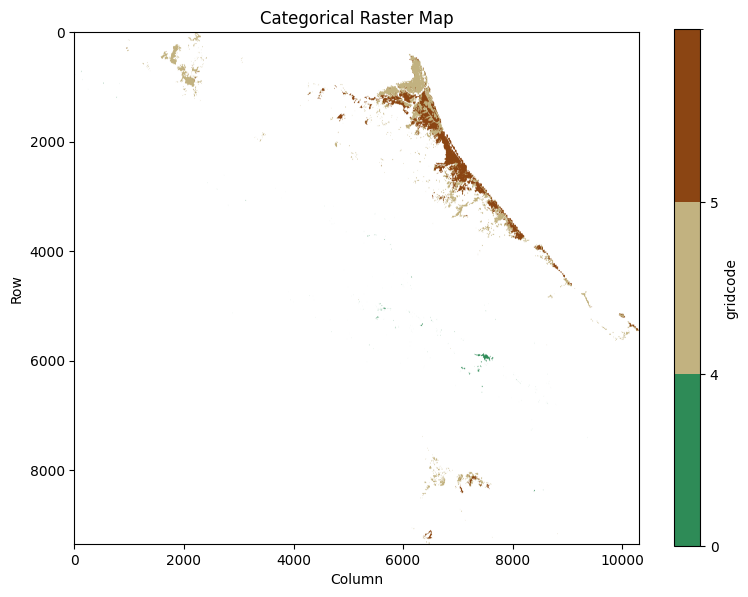

In [13]:
# Visualize raster

nodata_value = -9999   # must match rasterize(fill=...)

# Mask nodata so it appears white
masked = np.ma.masked_where(raster == nodata_value, raster)

# Get unique raster values (excluding nodata)
unique_values = np.unique(raster)
unique_values = unique_values[unique_values != nodata_value]

print("Unique classes:", unique_values)

# ---------------------------
# Custom 3-class colour scheme
# (Edit if you prefer others)
# ---------------------------
class_colors = [
    "#2E8B57",  # green
    "#C2B280",  # peat / beige
    "#8B4513"   # brown
]

cmap = ListedColormap(class_colors[:len(unique_values)])
cmap.set_bad(color="white")  # nodata = white

# Create boundaries for categorical mapping
bounds = np.append(unique_values, unique_values[-1] + 1)
norm = BoundaryNorm(bounds, cmap.N)

# Plot
plt.figure(figsize=(8, 6))
img = plt.imshow(masked, cmap=cmap, norm=norm)

cbar = plt.colorbar(img, ticks=unique_values)
cbar.set_label(attribute_field)

plt.title("Categorical Raster Map")
plt.xlabel("Column")
plt.ylabel("Row")
plt.tight_layout()
plt.show()

In [14]:
# Save raster

with rasterio.open(
    output_raster,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs=gdf.crs,
    transform=transform,
) as dst:
    dst.write(raster, 1)

print("Rasterization complete!")

Rasterization complete!
